# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** Anthony Mollica

**Date:** 3/27/2026

---

## Setup: Install and Load Libraries

In [34]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [35]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [36]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


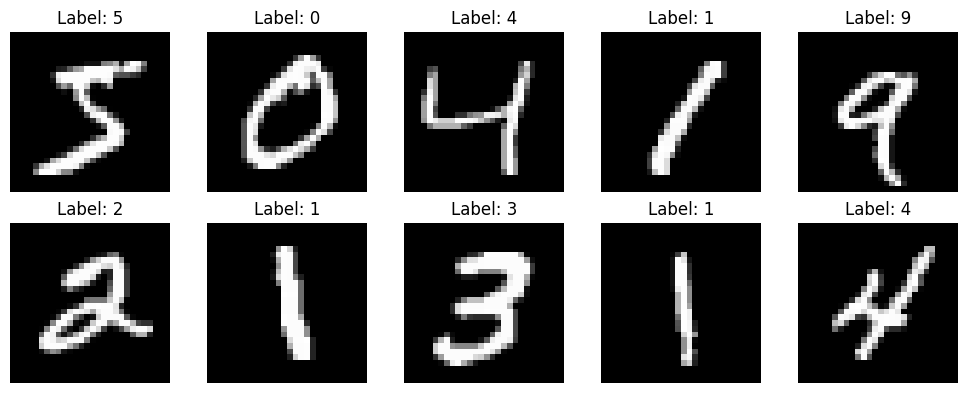

In [37]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [38]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [39]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential(
    [
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss
baseline_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



# Display model architecture
baseline_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)# Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(
    X_test_cnn,
    y_test
) # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.9568 - loss: 0.1431 - val_accuracy: 0.9855 - val_loss: 0.0508
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.9854 - loss: 0.0478 - val_accuracy: 0.9880 - val_loss: 0.0434
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9903 - loss: 0.0315 - val_accuracy: 0.9880 - val_loss: 0.0412
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9871 - loss: 0.0408

BASELINE CNN RESULTS
Final Training Accuracy: 0.9903
Final Validation Accuracy: 0.9880
Test Accuracy: 0.9871
Training Time: 109.76 seconds


---
## Step 3: Experiment with Filter Counts

In [43]:
# TODO: Build and train CNN with FEWER filters (16, 32)
cnn_fewer_filters = keras.Sequential(
    [
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)
# Keep all other architecture elements the same as baseline
cnn_fewer_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy
# Train model
history_fewer = cnn_fewer_filters.fit(
    X_train_cnn,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

# Record validation accuracy
fewer_val_accuracy = history_fewer.history['val_accuracy'][-1]

print(f"Validation Accuracy (Fewer Filters): {fewer_val_accuracy:.4f}")


c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN with fewer filters (16, 32)...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.9500 - loss: 0.1637 - val_accuracy: 0.9812 - val_loss: 0.0621
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9831 - loss: 0.0528 - val_accuracy: 0.9852 - val_loss: 0.0474
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9884 - loss: 0.0375 - val_accuracy: 0.9867 - val_loss: 0.0420
Validation Accuracy (Fewer Filters): 0.9867


In [54]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline
# Build CNN with more filters
cnn_more_filters = keras.Sequential(
    [
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

# Compile model
cnn_more_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
# Record validation accuracy
# Train model
history_more = cnn_more_filters.fit(
    X_train_cnn,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

# Record validation accuracy
more_val_accuracy = history_more.history['val_accuracy'][-1]

print(f"Validation Accuracy (More Filters): {more_val_accuracy:.4f}")

Training CNN with more filters (64, 128)...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 63s 30ms/step - accuracy: 0.9605 - loss: 0.1256 - val_accuracy: 0.9873 - val_loss: 0.0418
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9873 - loss: 0.0411 - val_accuracy: 0.9893 - val_loss: 0.0341
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9909 - loss: 0.0285 - val_accuracy: 0.9888 - val_loss: 0.0439
Validation Accuracy (More Filters): 0.9888


### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

Increasing the number of filters improves the model’s ability to learn more complex features, which increases accuracy. In this experiment, the CNN with more filters (64, 128) achieved a higher validation accuracy (0.9888) than the model with fewer filters (0.9867), but the improvement was small while training time increased significantly. This suggests diminishing returns, where adding more filters increases computational cost without producing a large gain in performance, and could eventually lead to overfitting if the model becomes too complex.

---
## Step 4: Experiment with Kernel Sizes

In [55]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)
# Build CNN with 5x5 kernels
cnn_medium_kernels = keras.Sequential(
    [
        layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

# Compile model
cnn_medium_kernels.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN with 5x5 kernels...")

# Train model
history_medium = cnn_medium_kernels.fit(
    X_train_cnn,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

# Record validation accuracy
medium_kernel_val_acc = history_medium.history['val_accuracy'][-1]

print(f"Validation Accuracy (5x5 Kernels): {medium_kernel_val_acc:.4f}")

c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN with 5x5 kernels...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9603 - loss: 0.1293 - val_accuracy: 0.9882 - val_loss: 0.0432
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accuracy: 0.9871 - loss: 0.0422 - val_accuracy: 0.9907 - val_loss: 0.0343
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9900 - val_loss: 0.0367
Validation Accuracy (5x5 Kernels): 0.9900


In [56]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)
cnn_mixed_kernels = keras.Sequential(
    [
        layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

# Compile model
cnn_mixed_kernels.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN with mixed kernels (5x5, 3x3)...")

# Train model
history_mixed = cnn_mixed_kernels.fit(
    X_train_cnn,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

# Record validation accuracy
mixed_kernel_val_acc = history_mixed.history['val_accuracy'][-1]

print(f"Validation Accuracy (Mixed Kernels): {mixed_kernel_val_acc:.4f}")

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 68s 39ms/step - accuracy: 0.9578 - loss: 0.1354 - val_accuracy: 0.9882 - val_loss: 0.0478
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.9864 - loss: 0.0443 - val_accuracy: 0.9910 - val_loss: 0.0347
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9899 - loss: 0.0312 - val_accuracy: 0.9903 - val_loss: 0.0330
Validation Accuracy (Mixed Kernels): 0.9903


### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Kernel size affects the scale of features a CNN learns from the image. Smaller kernels capture fine details such as edges, while larger kernels capture broader spatial patterns but may lose some local detail. In this case, the 5×5 kernel configuration performed very well with about 99.0% validation accuracy, likely because the larger field allowed the network to capture slightly more information from the images while still maintaining strong generalization.

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [57]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split

print("Training best CNN architecture...")
start_time = time.time()

# Build best CNN (mixed kernels: 5x5 first layer, 3x3 second layer)
best_cnn = keras.Sequential(
    [
        layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

# Compile model
best_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_best = best_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

best_cnn_time = time.time() - start_time

# Evaluate on test set
best_test_loss, best_test_acc = best_cnn.evaluate(
    X_test_cnn,
    y_test
)

# Print results
print("\n" + "="*80)
print("BEST CNN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history_best.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_best.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_cnn_time:.2f} seconds")
print("="*80)

Training best CNN architecture...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9565 - loss: 0.1385 - val_accuracy: 0.9805 - val_loss: 0.0626
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.9851 - loss: 0.0481 - val_accuracy: 0.9889 - val_loss: 0.0383
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9897 - loss: 0.0310 - val_accuracy: 0.9885 - val_loss: 0.0461
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9923 - loss: 0.0233 - val_accuracy: 0.9887 - val_loss: 0.0410
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9944 - loss: 0.0182 - val_accuracy: 0.9900 - val_loss: 0.0349
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accuracy: 0.9847 - val_loss: 0.0546
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9961 - loss: 0.0112 - val_accuracy: 0.9914 - val_loss: 0.0351
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

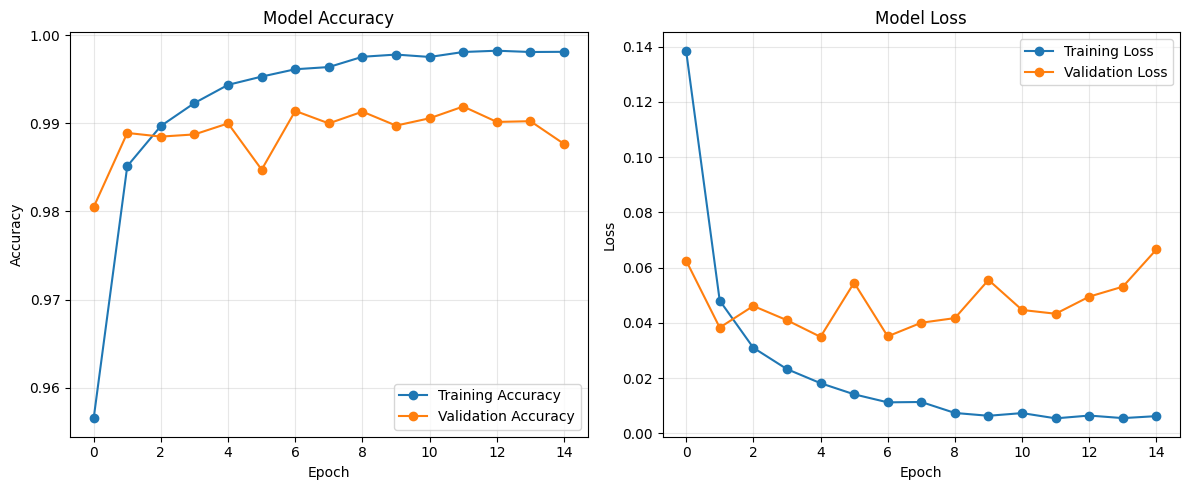

In [60]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)
# TODO: Plot training and validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_best.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_best.history['loss'], label='Training Loss', marker='o')
plt.plot(history_best.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [49]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [61]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation
from tensorflow import keras
from tensorflow.keras import layers

# Build feedforward network
feedforward_nn = keras.Sequential([
    layers.Input(shape=(784,)),           # Input layer (flattened 28x28 image)
    layers.Dense(128, activation='relu'), # First hidden layer
    layers.Dense(64, activation='relu'),  # Second hidden layer
    layers.Dense(10, activation='softmax')# Output layer (10 classes)
])

# Compile the model
feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
feedforward_nn.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
print("Training feedforward network...")
start_time = time.time()

# Train the feedforward network
history_ffnn = feedforward_nn.fit(
    X_train_flat,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1  # Use 10% of training data for validation
)

# Record training time
feedforward_time = time.time() - start_time

# Evaluate on test set
ffnn_test_loss, ffnn_test_acc = feedforward_nn.evaluate(X_test_flat, y_test)

# Print results
print("\n" + "="*80)
print("FEEDFORWARD NETWORK RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history_ffnn.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_ffnn.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {ffnn_test_acc:.4f}")
print(f"Training Time: {feedforward_time:.2f} seconds")
print("="*80)


Training feedforward network...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9803 - loss: 0.0630 - val_accuracy: 0.9745 - val_loss: 0.0795
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9843 - loss: 0.0483 - val_accuracy: 0.9757 - val_loss: 0.0838
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9868 - loss: 0.0395 - val_accuracy: 0.9782 - val_loss: 0.0741
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0794

FEEDFORWARD NETWORK RESULTS
Final Training Accuracy: 0.9868
Final Validation Accuracy: 0.9782
Test Accuracy: 0.9745
Training Time: 45.08 seconds


In [64]:
import pandas as pd

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv2D(32,3x3)->MaxPool->Conv2D(64,3x3)->MaxPool->Dense(128)->Dense(10)',
        'Conv2D(32,5x5)->MaxPool->Conv2D(64,3x3)->MaxPool->Dense(128)->Dense(10)',
        'Dense(128)->Dense(64)->Dense(10)'
    ],
    'Test Accuracy': [
        baseline_test_acc,   # From baseline CNN evaluation
        best_test_acc,       # From best CNN evaluation
        ffnn_test_acc        # From feedforward NN evaluation
    ],
    'Training Time (s)': [
        baseline_time,       # Recorded training time for baseline CNN
        best_cnn_time,       # Recorded training time for best CNN
        feedforward_time     # Recorded training time for feedforward NN
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                                                            Architecture  Test Accuracy  Training Time (s)
  Baseline CNN Conv2D(32,3x3)->MaxPool->Conv2D(64,3x3)->MaxPool->Dense(128)->Dense(10)         0.9871         109.763060
      Best CNN Conv2D(32,5x5)->MaxPool->Conv2D(64,3x3)->MaxPool->Dense(128)->Dense(10)         0.9906         503.157855
Feedforward NN                                        Dense(128)->Dense(64)->Dense(10)         0.9745          45.082560


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The best CNN outperforms the feedforward network, achieving a higher test accuracy (0.9906 vs 0.9745) despite longer training time. This is because the CNN leverages spatial structure in the images, using convolutional filters to detect local patterns and hierarchies, whereas the feedforward network treats each pixel independently and cannot efficiently capture edges, shapes, or other spatial features. As a result, the CNN is better at generalizing and recognizing digits from image data.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

For my Netflix movies project, CNNs would only be useful if the data includes images such as movie posters or frame snapshots, as CNNs can extract visual patterns that might correlate with genres or popularity. RNNs would be valuable if the project involves time series or sequential data, such as tracking user watch history or ratings over time, because RNNs can capture dependencies and trends. If the dataset ends up being mostly tabular (e.g., movie metadata, user demographics, or transaction records), then feedforward networks or traditional ML models like Random Forests or Gradient Boosting remain appropriate, as they handle features efficiently without needing spatial or sequential modeling. Using specialized architectures like CNNs or RNNs would improve the solution only when the data contains visual, sequential, or text information, enabling the model to extract patterns that a standard feedforward network might miss.

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.